In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os

In [34]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [35]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path to dataset files: /kaggle/input/mnist-dataset


In [38]:
dataset_path = '/content/sample_data'

In [39]:
df = pd.read_csv(os.path.join(dataset_path, "mnist_train_small.csv"))

In [40]:
df.head(5)

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
df.shape

(19999, 785)

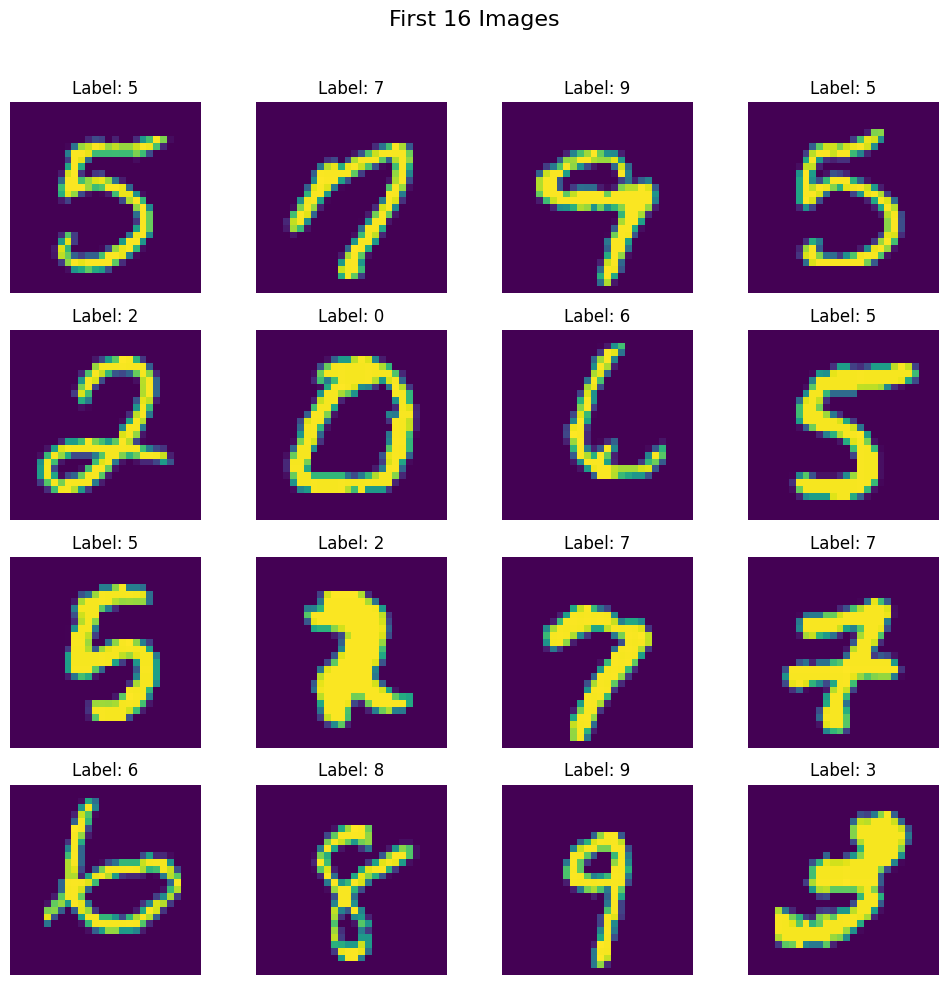

In [42]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [43]:
x = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [44]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [45]:
X_train = X_train/255.0
X_test = X_test/255.0

In [46]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [47]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [48]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [50]:
class MyNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*3*3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [51]:
learning_rate = 0.001
epochs = 100

In [54]:
model = MyNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [55]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 1.76220374250412
Epoch: 2 , Loss: 0.9105782096385956
Epoch: 3 , Loss: 0.542548500418663
Epoch: 4 , Loss: 0.38497228413820267
Epoch: 5 , Loss: 0.3017179419994354
Epoch: 6 , Loss: 0.2512447890937328
Epoch: 7 , Loss: 0.21687937000393867
Epoch: 8 , Loss: 0.1911077165901661
Epoch: 9 , Loss: 0.17313611733913423
Epoch: 10 , Loss: 0.15718477174639703
Epoch: 11 , Loss: 0.14572692769765855
Epoch: 12 , Loss: 0.1377333288937807
Epoch: 13 , Loss: 0.12465486125648022
Epoch: 14 , Loss: 0.12125793991982937
Epoch: 15 , Loss: 0.11308263905346394
Epoch: 16 , Loss: 0.10436806185543537
Epoch: 17 , Loss: 0.09832788190245628
Epoch: 18 , Loss: 0.09365678683668376
Epoch: 19 , Loss: 0.08994663643836975
Epoch: 20 , Loss: 0.08695054849237203
Epoch: 21 , Loss: 0.08113925855606795
Epoch: 22 , Loss: 0.07833469766378402
Epoch: 23 , Loss: 0.07355289731174708
Epoch: 24 , Loss: 0.07234918343648314
Epoch: 25 , Loss: 0.06746861649304628
Epoch: 26 , Loss: 0.06835299681127072
Epoch: 27 , Loss: 0.06533930192

In [56]:
model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0

In [57]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9825


In [58]:
# evaluation on training data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

1.0


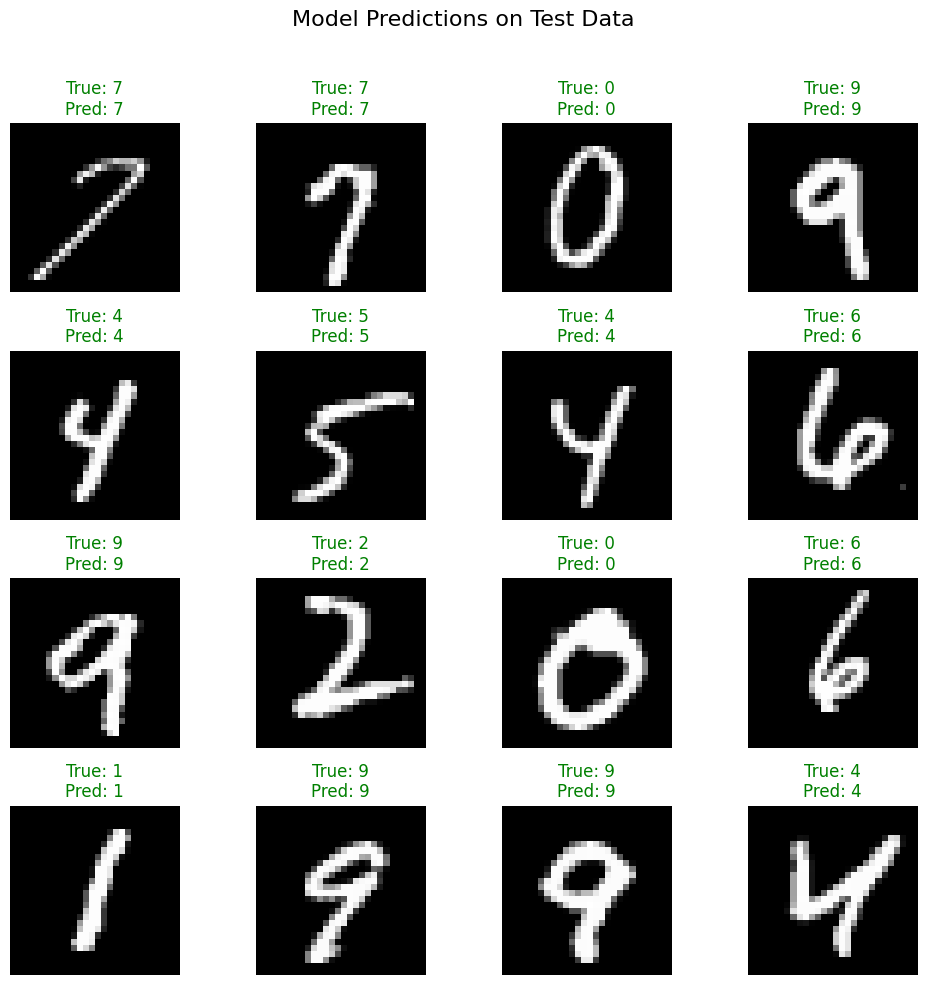

In [59]:
model.eval()

# Get a batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move images and labels to the device (CPU/GPU)
images, labels = images.to(device), labels.to(device)

# Make predictions
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Plot the images with true and predicted labels
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Model Predictions on Test Data", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = images[i].cpu().numpy().reshape(28, 28) # Reshape for plotting
        ax.imshow(img, cmap='gray') # Display in grayscale
        ax.axis('off') # Remove axis
        color = 'green' if predicted[i] == labels[i] else 'red'
        ax.set_title(f"True: {labels[i].item()}\nPred: {predicted[i].item()}", color=color)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to fit title
plt.show()

Epoch 1/100, Loss: 0.0036
Epoch 2/100, Loss: 0.0031
Epoch 3/100, Loss: 0.0028
Epoch 4/100, Loss: 0.0026
Epoch 5/100, Loss: 0.0025
Epoch 6/100, Loss: 0.0023
Epoch 7/100, Loss: 0.0022
Epoch 8/100, Loss: 0.0021
Epoch 9/100, Loss: 0.0021
Epoch 10/100, Loss: 0.0020
Epoch 11/100, Loss: 0.0019
Epoch 12/100, Loss: 0.0018
Epoch 13/100, Loss: 0.0018
Epoch 14/100, Loss: 0.0017
Epoch 15/100, Loss: 0.0017
Epoch 16/100, Loss: 0.0016
Epoch 17/100, Loss: 0.0016
Epoch 18/100, Loss: 0.0016
Epoch 19/100, Loss: 0.0015
Epoch 20/100, Loss: 0.0015
Epoch 21/100, Loss: 0.0015
Epoch 22/100, Loss: 0.0014
Epoch 23/100, Loss: 0.0014
Epoch 24/100, Loss: 0.0014
Epoch 25/100, Loss: 0.0013
Epoch 26/100, Loss: 0.0013
Epoch 27/100, Loss: 0.0013
Epoch 28/100, Loss: 0.0012
Epoch 29/100, Loss: 0.0012
Epoch 30/100, Loss: 0.0012
Epoch 31/100, Loss: 0.0012
Epoch 32/100, Loss: 0.0012
Epoch 33/100, Loss: 0.0011
Epoch 34/100, Loss: 0.0011
Epoch 35/100, Loss: 0.0011
Epoch 36/100, Loss: 0.0011
Epoch 37/100, Loss: 0.0011
Epoch 38/1

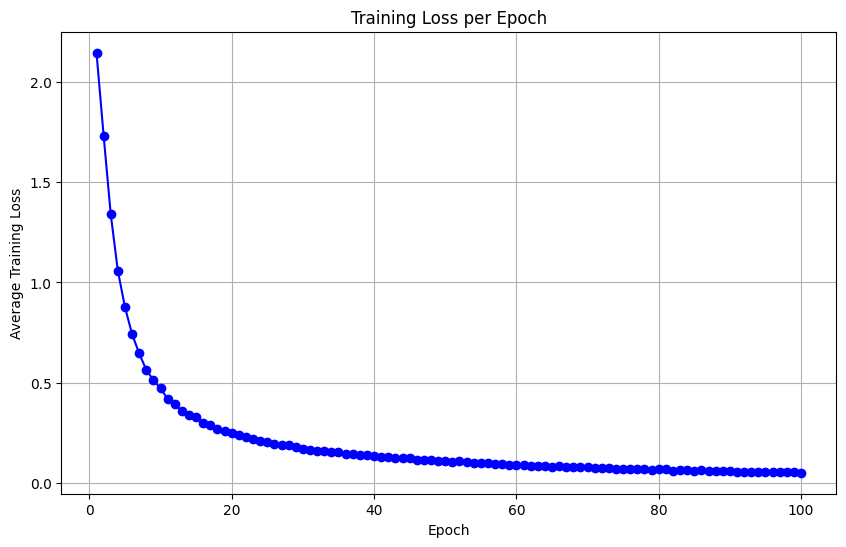

In [62]:
epochs = 100
train_losses = []

for epoch in range(epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), actual_losses, marker='o', linestyle='-', color='blue')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Training Loss')
plt.grid(True)
plt.show()

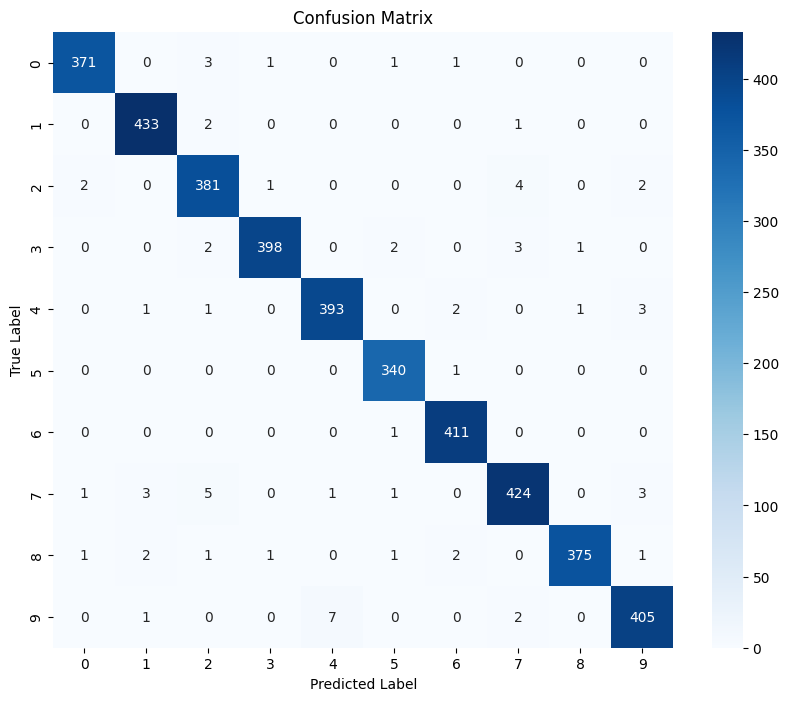


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       377
           1       0.98      0.99      0.99       436
           2       0.96      0.98      0.97       390
           3       0.99      0.98      0.99       406
           4       0.98      0.98      0.98       401
           5       0.98      1.00      0.99       341
           6       0.99      1.00      0.99       412
           7       0.98      0.97      0.97       438
           8       0.99      0.98      0.99       384
           9       0.98      0.98      0.98       415

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



In [63]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Put the model in evaluation mode
model.eval()

all_preds = []
all_labels = []

# Disable gradient calculations for inference
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

# Generate Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
class_report = classification_report(all_labels, all_preds)
print("\nClassification Report:")
print(class_report)